In [1]:
import tensorflow as tf
print(tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2.10.0
Num GPUs Available: 1


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf
import scipy

In [3]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.10.0
Num GPUs Available: 1


In [ ]:
#Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=150.0
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r"C:\Users\hasna\Projects\ML ImageNet Project\backup\tiny_imagenet\tiny-imagenet-200\train"
val_dir = r"C:\Users\hasna\Projects\ML ImageNet Project\backup\tiny_imagenet\tiny-imagenet-200\val"

In [ ]:
#Data Loaders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical'
)

Found 100000 images belonging to 200 classes.
Found 10000 images belonging to 200 classes.


CNN

In [ ]:
#Basic CNN Architecture

import os
from tensorflow.keras.models import load_model

model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\cnn_model_full.h5"

#Using saved model if exists
if os.path.exists(model_path):
    print("Loading saved CNN model...")
    model = load_model(model_path)
    model_loaded = True
else:
    model_loaded = False
    print("Training CNN model from scratch...")

    
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(2048, activation='relu'),
        Dropout(0.5),
        Dense(200, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    tf.debugging.set_log_device_placement(True)

Loading saved CNN model...


In [ ]:
#Training the model - if pre existing model not found
if not model_loaded:
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=30,
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size
    )

In [ ]:
if not model_loaded:
    import json
    #Save CNN Training History, Architecture and weights
    with open("cnn_training_metrics.json", "w") as f:
        json.dump(history.history, f)
    
    with open("cnn_model_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    model.save("cnn_model_full.h5")

ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import SGD

model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models/resnet50_sgd_model.h5"

if os.path.exists(model_path):
    print("Loading saved ResNet50 (SGD) model...")
    model = load_model(model_path)
    model_loaded = True
else:
    print("Training ResNet50 (SGD) model from scratch...")
    model_loaded = False


    #Loading weights + Pre trained model from imagenet
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64,64,3))

    # #Freeze the base layers
    for layer in base_model.layers[:84]:  #Freeze the initial layers
        layer.trainable = False
    for layer in base_model.layers[84:]:  #Unfreeze the later layers
        layer.trainable = True

    # for layer in base_model.layers:
    #   layer.trainable=True

    #add custom layers on top of base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    # x = BatchNormalization()(x)
    # x = Dropout(0.3)(x)
    # x = Dense(1024, activation='relu')(x)  # Additional Dense layer
    # x = BatchNormalization()(x)  # Batch Normalization layer
    x = Dropout(0.5)(x)
    predictions = Dense(200, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    # model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    optimizer = SGD(learning_rate=0.001, momentum=0.9)

    #Compile the model with SGD
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

Loading saved ResNet50 (SGD) model...


In [ ]:
if not model_loaded:
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    from tensorflow.keras.callbacks import EarlyStopping

    #Initialize ReduceLROnPlateau callback
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor the validation loss
        patience= 3,          #Stop after 3 epochs with no improvement
        restore_best_weights=True
    )

    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=30,  
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        callbacks=[reduce_lr, early_stopping]  #Add both ReduceLROnPlateau and Early Stopping
    )

In [ ]:
if not model_loaded:
    import json

    #Saving Model Training History
    #Convert all values in history.history to standard Python types
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}

    with open("resnet50_sgd_metrics.json", "w") as f:
        json.dump(history_dict, f)


    with open("resnet50_sgd_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    model.save("resnet50_sgd_model.h5")

**Resnet 50 with no frozen Layers:**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import SGD

model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\resnet50_adam_full_model.h5"

if os.path.exists(model_path):
    print("Loading saved ResNet50 (Adam) model...")
    model = load_model(model_path)
    model_loaded = True
else:
    print("Training ResNet50 (Adam) model from scratch...")
    model_loaded = False
    #Loading weights + Pre trained model from imagenet
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64,64,3))

    # # #Freeze the base layers
    # for layer in base_model.layers[:84]:  # Freeze the initial layers
    #     layer.trainable = False
    # for layer in base_model.layers[84:]:  # Unfreeze the later layers
    #     layer.trainable = True

    for layer in base_model.layers:
      layer.trainable=True

    #add custom layers on top of base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    # x = BatchNormalization()(x)
    # x = Dropout(0.3)(x)
    # x = Dense(1024, activation='relu')(x)  # Additional Dense layer
    # x = BatchNormalization()(x)  # Batch Normalization layer
    x = Dropout(0.5)(x)
    predictions = Dense(200, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    # optimizer = SGD(learning_rate=0.001, momentum=0.9)

    # Compile the model with SGD
    # model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

Loading saved ResNet50 (Adam) model...


In [ ]:
if not model_loaded:
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    from tensorflow.keras.callbacks import EarlyStopping

    #Initialize ReduceLROnPlateau callback
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

    early_stopping = EarlyStopping(
        monitor='val_loss',  #Monitor the validation loss
        patience= 6,          #Stop after 3 epochs with no improvement
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=60,  #Train for a higher number of epochs
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        callbacks=[reduce_lr, early_stopping]  #Add both ReduceLROnPlateau and Early Stopping
    )

In [ ]:
if not model_loaded:
    import json

    #Convert float32 values to float - so that they can be saved in json file
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}

    #Save Training History, model in json file
    with open("resnet50_adam_full_metrics.json", "w") as f:
        json.dump(history_dict, f)

    with open("resnet50_adam_full_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    model.save("resnet50_adam_full_model.h5")

MobileNet

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD

model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\mobilenet_model.h5"

if os.path.exists(model_path):
    print("Loading saved MobileNet model...")
    model = load_model(model_path)
    model_loaded = True
else:
    print("Training MobileNet model from scratch...")
    model_loaded = False
    # Load MobileNet with ImageNet weights
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)  
    x = Dropout(0.3)(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(200, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    # optimizer = Adam(learning_rate=0.0001)  # Custom learning rate
    optimizer = SGD(learning_rate=0.001, momentum=0.9)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()  

Loading saved MobileNet model...


In [19]:
if not model_loaded:
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )

    # def scheduler(epoch, lr):
    #     if epoch < 10:
    #         return float(lr)
    #     else:
    #         return float(lr * tf.math.exp(-0.1))

    # lr_scheduler = LearningRateScheduler(scheduler)

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

In [20]:
if not model_loaded:

    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=50,
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        callbacks=[reduce_lr, early_stopping]
    )

In [ ]:
if not model_loaded:
    import json

    #Convert and save training history
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open("mobilenet_training_metrics.json", "w") as f:
        json.dump(history_dict, f)

    #Save model summary and model
    with open("mobilenet_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    model.save("mobilenet_model.h5")

EfficientNet

In [ ]:
import os
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Path to the uploaded weights file, since the model was not saved
weights_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\effnetb0_weights.h5"

#Rebuild EfficientNetB0 architecture
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(200, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

#Load the weights
if os.path.exists(weights_path):
    print("Loading EfficientNetB0 weights...")
    model.load_weights(weights_path)
    model_loaded = True
else:
    print("Training EfficientNetB0 model from scratch...")
    model_loaded = False
    model.summary()

Loading EfficientNetB0 weights...


In [ ]:
if not model_loaded:
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',  #Monitors the validation loss
        factor=0.5,  #Reduces the learning rate by a factor of 0.5
        patience=3,  #Waits for 3 epochs before reducing the LR
        min_lr=0.00001,  #Sets the minimum learning rate
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',  #Monitor validation loss for early stopping
        patience=5,  #Stop after 5 epochs with no improvement
        restore_best_weights=True,  #Restores weights from the best epoch
        verbose=1
    )

    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=30,  #Adjust epochs based on your needs
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        callbacks=[reduce_lr, early_stopping]  # Add callbacks
    )

    model.save_weights("effnetb0_weights.h5")

    #Save training metrics
    import json
    with open("effnetb0_training_metrics.json", "w") as f:
        json.dump(history.history, f)

    print("Training complete. Weights and metrics saved.")
    print("Accuracy (first 5):", history.history['accuracy'][:5])
    print("Val Accuracy (first 5):", history.history['val_accuracy'][:5])

In [64]:
# import json

# # === Convert and save metrics ===
# history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
# with open("effnetb0_training_metrics.json", "w") as f:
#     json.dump(history_dict, f)

# # === Save model summary ===
# with open("effnetb0_summary.txt", "w") as f:
#     model.summary(print_fn=lambda x: f.write(x + "\n"))

# # === Save trained model ===
# model.save("effnetb0_model.h5")

In [ ]:
import os
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Path to weights file only since model could not be saved
weights_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\effnetb3_weights.h5"

#Rebuild model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

#Unfreeze selected layers
for layer in base_model.layers[:100]:
    layer.trainable = True

#Adding custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(200, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

#load weights if they exist
if os.path.exists(weights_path):
    print("Loading EfficientNetB3 weights...")
    model.load_weights(weights_path)
    model_loaded = True
else:
    print("Training EfficientNetB3 model from scratch...")
    model_loaded = False
    model.summary()

Loading EfficientNetB3 weights...


In [ ]:
if not model_loaded:
    #Callbacks for training
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',  
        factor=0.5,  #Reduces the learning rate by a factor of 0.5
        patience=3,  #Waits for 3 epochs before reducing the LR
        min_lr=0.00001,  #Minimum learning rate
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',  
        patience=5,  
        restore_best_weights=True,  #Restores weights from the best epoch
        verbose=1
    )

    #train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        epochs=100,  #Train for a higher number of epochs
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        callbacks=[reduce_lr, early_stopping]  #Add callbacks
    )

In [ ]:
if not model_loaded:
    import json

    #Save EfficientNetB3 Training Metrics
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open("effnetb3_training_metrics.json", "w") as f:
        json.dump(history_dict, f)


    with open("effnetb3_summary.txt", "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))

    # === Save Trained Model ===
    # model.save('tiny_imagenet_Efficientnetb3.h5')

In [72]:
if not model_loaded:
    model.save_weights("effnetb3_weights.h5")

**FEW SHOT LEARNING**

1. With Pre-trained models.

In [33]:
from tensorflow.keras.models import load_model
model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\resnet50_adam_full_model.h5"
#Load ResNet50 model
resnet_model = load_model(model_path)

#Load MobileNet model
model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\mobilenet_model.h5"
mobilenet_model = load_model(model_path)

In [73]:
# Example for EfficientNetB3
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Rebuild the model architecture
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(200, activation='softmax')(x)

efficientnet_model = Model(inputs=base_model.input, outputs=predictions)
weights_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\effnetb3_weights.h5"
efficientnet_model.load_weights(weights_path)

In [35]:
#Evaluate ResNet50
val_generator.batch_size = 4
resnet_loss, resnet_accuracy = resnet_model.evaluate(val_generator, verbose=1)
print(f'ResNet50 Accuracy: {resnet_accuracy * 100:.2f}%')

#Evaluate MobileNet
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(val_generator, verbose=1)
print(f'MobileNet Accuracy: {mobilenet_accuracy * 100:.2f}%')

2500/2500 [==============================] - 23s 8ms/step - loss: 2.0003 - accuracy: 0.5272
ResNet50 Accuracy: 52.72%
2500/2500 [==============================] - 8s 3ms/step - loss: 2.2361 - accuracy: 0.4624
MobileNet Accuracy: 46.24%


In [ ]:
#Evaluate EfficientNet B3
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Rebuild the architecture
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
for layer in base_model.layers[:100]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(200, activation='softmax')(x)

efficientnet_model = Model(inputs=base_model.input, outputs=predictions)

efficientnet_model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

#Load saved weights
weights_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\effnetb3_weights.h5"
efficientnet_model.load_weights(weights_path)

loss, acc = efficientnet_model.evaluate(val_generator, verbose=1)
print(f"EfficientNet B3 Accuracy: {acc * 100:.2f}%")


2500/2500 [==============================] - 27s 10ms/step - loss: 2.2405 - accuracy: 0.4676
EfficientNet B3 Accuracy: 46.76%


With ResNet50:

In [38]:
from tensorflow.keras.models import load_model

#Load the ResNet50 model previously saved
model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\resnet50_adam_full_model.h5"
resnet_model = load_model(model_path)

#Check the model summary to ensure it's loaded correctly
resnet_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 70, 70, 3)    0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 32, 32, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 32, 32, 64)   256         ['conv1_conv[0][0]']             
                                                                                            

In [39]:
from tensorflow.keras import Model

#Create a new model that outputs the feature vectors
feature_extractor = Model(inputs=resnet_model.input, outputs=resnet_model.layers[-2].output)

#Check the model summary (this should stop at the second-to-last layer)
feature_extractor.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 70, 70, 3)    0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 32, 32, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 32, 32, 64)   256         ['conv1_conv[0][0]']             
                                                                                            

In [40]:
print(val_generator.samples)

10000


Batch size = 16
Hence, 10,000/16 = 625 batches

In [ ]:
import gc
import numpy as np
import os

batch_size = val_generator.batch_size
print(f"Current val_generator batch size: {batch_size}")

N = 5  # number of support images per class
max_batches = 625

for i, (batch_images, batch_labels) in enumerate(val_generator):
    if i >= max_batches:
        break

    print(f"Processing batch {i + 1}...")
    print(f"batch_images shape: {batch_images.shape}, batch_labels shape: {batch_labels.shape}")

    current_N = min(N, batch_images.shape[0] // 2)
    print(f"Using N={current_N} support images")

    support_batch_images = batch_images[:current_N]
    query_batch_images = batch_images[current_N:]

    support_batch_labels = batch_labels[:current_N]
    query_batch_labels = batch_labels[current_N:]

    print(f"Support labels shape: {support_batch_labels.shape}, Query labels shape: {query_batch_labels.shape}")

    support_batch_features = feature_extractor.predict_on_batch(support_batch_images)

    if query_batch_images.shape[0] > 0:
        query_batch_features = feature_extractor.predict_on_batch(query_batch_images)
    else:
        query_batch_features = np.array([]).reshape(0, support_batch_features.shape[1])  # Empty with correct dims

    np.save(f'features/support_features_batch_{i}.npy', support_batch_features)
    np.save(f'features/query_features_batch_{i}.npy', query_batch_features)
    np.save(f'features/support_labels_batch_{i}.npy', support_batch_labels)
    np.save(f'features/query_labels_batch_{i}.npy', query_batch_labels)

    print(f"Batch {i + 1} processed and saved.")

    del batch_images, batch_labels, support_batch_images, query_batch_images
    del support_batch_features, query_batch_features, support_batch_labels, query_batch_labels
    gc.collect()


#Load saved batches using local path style and old logic

features_dir = r'C:\Users\hasna\Projects\ML ImageNet Project\features'

all_support_features = []
all_support_labels = []
all_query_features = []
all_query_labels = []

for i in range(max_batches):
    try:
        support_features_batch = np.load(os.path.join(features_dir, f'support_features_batch_{i}.npy'))
        query_features_batch = np.load(os.path.join(features_dir, f'query_features_batch_{i}.npy'))

        support_labels_batch = np.load(os.path.join(features_dir, f'support_labels_batch_{i}.npy'))
        query_labels_batch = np.load(os.path.join(features_dir, f'query_labels_batch_{i}.npy'))

        support_labels_batch = np.argmax(support_labels_batch, axis=1)
        query_labels_batch = np.argmax(query_labels_batch, axis=1)

        all_support_features.append(support_features_batch)
        all_query_features.append(query_features_batch)
        all_support_labels.append(support_labels_batch)
        all_query_labels.append(query_labels_batch)

        print(f"Loaded batch {i + 1} features and labels.")

    except FileNotFoundError:
        print(f"Batch {i + 1} files not found, skipping.")

all_support_features = np.vstack(all_support_features)
all_query_features = np.vstack(all_query_features)

all_support_labels = np.concatenate(all_support_labels)
all_query_labels = np.concatenate(all_query_labels)

print(f"All support features shape: {all_support_features.shape}")
print(f"All query features shape: {all_query_features.shape}")
print(f"All support labels shape: {all_support_labels.shape}")
print(f"All query labels shape: {all_query_labels.shape}")

#Prototype computation and classification (old working functions)

def compute_prototypes_in_batches(support_features, support_labels, num_classes, batch_size=500):
    prototypes = np.zeros((num_classes, support_features.shape[1]))
    class_counts = np.zeros(num_classes)

    for i in range(0, len(support_features), batch_size):
        batch_features = support_features[i:i + batch_size]
        batch_labels = support_labels[i:i + batch_size]

        for class_idx in range(num_classes):
            class_mask = batch_labels == class_idx
            class_features = batch_features[class_mask]

            if len(class_features) > 0:
                prototypes[class_idx] += np.sum(class_features, axis=0)
                class_counts[class_idx] += len(class_features)

    for class_idx in range(num_classes):
        if class_counts[class_idx] > 0:
            prototypes[class_idx] /= class_counts[class_idx]

    return prototypes

def classify_query_images_in_batches(query_features, prototypes, batch_size=1000):
    predicted_labels = []
    for i in range(0, len(query_features), batch_size):
        query_batch = query_features[i:i + batch_size]
        distances = np.linalg.norm(query_batch[:, np.newaxis] - prototypes, axis=2)
        predicted_labels_batch = np.argmin(distances, axis=1)
        predicted_labels.extend(predicted_labels_batch)
    return np.array(predicted_labels)

num_classes = len(np.unique(all_support_labels))
prototypes = compute_prototypes_in_batches(all_support_features, all_support_labels, num_classes)

predicted_labels = classify_query_images_in_batches(all_query_features, prototypes)

#Accuracy Calculation

from sklearn.metrics import accuracy_score

predicted_labels = np.array(predicted_labels).flatten()
all_query_labels = np.array(all_query_labels).flatten()

print("Predicted labels shape:", predicted_labels.shape)
print("Query labels shape:", all_query_labels.shape)

accuracy = accuracy_score(all_query_labels, predicted_labels)
print(f"Few-shot accuracy: {accuracy * 100:.2f}%")


Current val_generator batch size: 4
Processing batch 1...
batch_images shape: (4, 64, 64, 3), batch_labels shape: (4, 200)
Using N=2 support images
Support labels shape: (2, 200), Query labels shape: (2, 200)
Batch 1 processed and saved.
Processing batch 2...
batch_images shape: (4, 64, 64, 3), batch_labels shape: (4, 200)
Using N=2 support images
Support labels shape: (2, 200), Query labels shape: (2, 200)
Batch 2 processed and saved.
Processing batch 3...
batch_images shape: (4, 64, 64, 3), batch_labels shape: (4, 200)
Using N=2 support images
Support labels shape: (2, 200), Query labels shape: (2, 200)
Batch 3 processed and saved.
Processing batch 4...
batch_images shape: (4, 64, 64, 3), batch_labels shape: (4, 200)
Using N=2 support images
Support labels shape: (2, 200), Query labels shape: (2, 200)
Batch 4 processed and saved.
Processing batch 5...
batch_images shape: (4, 64, 64, 3), batch_labels shape: (4, 200)
Using N=2 support images
Support labels shape: (2, 200), Query labels

In [87]:
import json

resnet_loss = resnet_loss if 'resnet_loss' in locals() else None
resnet_accuracy = resnet_accuracy if 'resnet_accuracy' in locals() else None
mobilenet_loss = mobilenet_loss if 'mobilenet_loss' in locals() else None
mobilenet_accuracy = mobilenet_accuracy if 'mobilenet_accuracy' in locals() else None
loss = loss if 'loss' in locals() else None
acc = acc if 'acc' in locals() else None
accuracy = accuracy if 'accuracy' in locals() else None

results = {
    "resnet50": {"loss": resnet_loss, "accuracy": resnet_accuracy},
    "mobilenet": {"loss": mobilenet_loss, "accuracy": mobilenet_accuracy},
    "efficientnetb3": {"loss": loss, "accuracy": acc},
    "few_shot": {"accuracy": float(accuracy) if accuracy is not None else None}
}

with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

Prototypical Network:

In [43]:
print(all_support_features.shape)
print(all_query_features.shape)
print(all_support_labels.shape)
print(all_query_labels.shape)

(1250, 512)
(1250, 512)
(1250,)
(1250,)


In [44]:
print(all_support_features.shape)
print(all_support_labels.shape)

(1250, 512)
(1250,)


In [45]:
all_support_labels = all_support_labels.flatten()
print(all_support_labels.shape)

(1250,)


In [ ]:
import numpy as np

proto_model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\proto_prototypes.npy"

#Load saved prototypes if available
if os.path.exists(proto_model_path):
    print("✅ Loading saved Prototypical Network prototypes...")
    prototypes = np.load(proto_model_path)

else:
    print("Saved prototypes not found. Computing from support data...")

    #Compute Prototypes in smaller batches
    def compute_prototypes_in_batches(support_features, support_labels, num_classes, batch_size=500):
        prototypes = np.zeros((num_classes, support_features.shape[1]))  # Shape: (num_classes, feature_dim)
        class_counts = np.zeros(num_classes)  # To keep track of how many support images per class

        #Process support features in batches
        for i in range(0, len(support_features), batch_size):
            batch_features = support_features[i:i + batch_size]
            batch_labels = support_labels[i:i + batch_size]

            for class_idx in range(num_classes):
                class_mask = batch_labels == class_idx
                class_features = batch_features[class_mask]

                if len(class_features) > 0:
                    prototypes[class_idx] += np.sum(class_features, axis=0)
                    class_counts[class_idx] += len(class_features)

        #Normalize the prototypes
        for class_idx in range(num_classes):
            if class_counts[class_idx] > 0:
                prototypes[class_idx] /= class_counts[class_idx]

        return prototypes

    #Classify query images in smaller chunks to reduce memory usage
    def classify_query_images_in_batches(query_features, prototypes, batch_size=1000):
        predicted_labels = []
        #Process query features in smaller batches
        for i in range(0, len(query_features), batch_size):
            query_batch = query_features[i:i + batch_size]

            #Compute the distance to the prototypes
            distances = np.linalg.norm(query_batch[:, np.newaxis] - prototypes, axis=2)

            #Predict labels (class with minimum distance)
            predicted_labels_batch = np.argmin(distances, axis=1)
            predicted_labels.extend(predicted_labels_batch)

        return np.array(predicted_labels)

    #Set the number of classes and batch sizes
    num_classes = len(np.unique(all_support_labels))  #  number of classes
    batch_size_prototypes = 500  #Batch size for computing prototypes
    batch_size_query = 1000  #Batch size for query set classification

    #Compute prototypes (small batches)
    prototypes = compute_prototypes_in_batches(all_support_features, all_support_labels, num_classes, batch_size=batch_size_prototypes)

    #Classify the query images (small batches)
    predicted_labels = classify_query_images_in_batches(all_query_features, prototypes, batch_size=batch_size_query)

    #Print the results
    print(f"Predicted labels for query images: {predicted_labels[:10]}")  # Display the first 10 predicted labels
    np.save(proto_model_path, prototypes)

🔄 Saved prototypes not found. Computing from support data...
Predicted labels for query images: [ 74 185  68  78 152 157 181  53 152  43]


In [47]:
from sklearn.metrics import accuracy_score

#Assuming `all_query_labels` contains the true labels for the query set
accuracy = accuracy_score(all_query_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 43.36%


In [ ]:
import json

#Load existing results if file exists
if os.path.exists("evaluation_results.json"):
    with open("evaluation_results.json", "r") as f:
        results = json.load(f)
else:
    results = {}

#Add/update prototypical network results
results["prototypical_network"] = {
    "accuracy": float(accuracy)
}

#Save updated results
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

Siamese Networks

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
import os
import json

#Paths
siamese_model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\siamese_model.h5"
siamese_history_path = "siamese_training_metrics.json"

#Contrastive Loss
def contrastive_loss(y_true, y_pred, margin=1):
    y_true = tf.cast(y_true, y_pred.dtype)
    squared_pred = K.square(y_pred)
    squared_margin = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * squared_pred + (1 - y_true) * squared_margin)

#Build Siamese Model
def build_siamese_model():
    input_a = layers.Input(shape=(512,))
    input_b = layers.Input(shape=(512,))
    diff = layers.Lambda(lambda tensors: K.abs(tensors[0] - tensors[1]))([input_a, input_b])
    output = layers.Dense(1, activation='sigmoid')(diff)
    model = Model(inputs=[input_a, input_b], outputs=output)
    return model

#Create Pairs
def create_siamese_pairs(support_features, support_labels, num_pairs=1000):
    pairs, labels = [], []
    unique_classes = np.unique(support_labels)
    
    while len(pairs) < num_pairs * 2:
        class_idx = np.random.choice(unique_classes)
        class_indices = np.where(support_labels == class_idx)[0]
        if len(class_indices) < 2:
            continue
        pos_idx = np.random.choice(class_indices, 2, replace=False)
        pairs.append([support_features[pos_idx[0]], support_features[pos_idx[1]]])
        labels.append(1)

        neg_classes = unique_classes[unique_classes != class_idx]
        neg_class = np.random.choice(neg_classes)
        neg_class_indices = np.where(support_labels == neg_class)[0]
        if len(neg_class_indices) < 2:
            continue
        neg_idx = np.random.choice(neg_class_indices, 2, replace=False)
        pairs.append([support_features[neg_idx[0]], support_features[neg_idx[1]]])
        labels.append(0)
    
    return np.array(pairs), np.array(labels)

#Load or Train Siamese Model
if os.path.exists(siamese_model_path):
    print("Loading saved Siamese model...")
    siamese_model = tf.keras.models.load_model(siamese_model_path, custom_objects={"contrastive_loss": contrastive_loss})
    model_loaded = True
else:
    print("🔄 Training Siamese model from scratch...")
    model_loaded = False

    #Generate training pairs
    pairs, labels = create_siamese_pairs(all_support_features, all_support_labels, num_pairs=2000)

    #Train model
    siamese_model = build_siamese_model()
    siamese_model.compile(optimizer='adam', loss=contrastive_loss, metrics=['accuracy'])
    history = siamese_model.fit([pairs[:, 0], pairs[:, 1]], labels, epochs=10, batch_size=32)

    #Save model and metrics
    siamese_model.save(siamese_model_path)

    with open(siamese_history_path, "w") as f:
        json.dump(history.history, f)

Loading saved Siamese model...


In [ ]:
#Batch Predict Similarity (memory-friendly)
def batch_predict_similarity_safe(query_features, support_features, support_labels, model, threshold=0.3, batch_size=16, inner_batch_size=256):
    predicted_labels = []
    num_queries = len(query_features)
    num_support = len(support_features)

    for i in range(0, num_queries, batch_size):
        query_batch = query_features[i:i + batch_size]
        batch_actual = len(query_batch)

        similarities = np.zeros((batch_actual, num_support), dtype=np.float32)

        for j in range(0, batch_actual * num_support, inner_batch_size):
            end_j = min(j + inner_batch_size, batch_actual * num_support)

            pairs_a = []
            pairs_b = []

            for idx in range(j, end_j):
                q_idx = idx // num_support
                s_idx = idx % num_support
                pairs_a.append(query_batch[q_idx])
                pairs_b.append(support_features[s_idx])

            pairs_a = np.array(pairs_a)
            pairs_b = np.array(pairs_b)

            preds = model.predict([pairs_a, pairs_b], verbose=0).flatten()

            for k, val in enumerate(preds):
                global_idx = j + k
                q_idx = global_idx // num_support
                s_idx = global_idx % num_support
                similarities[q_idx, s_idx] = val

        max_sims = np.max(similarities, axis=1)
        max_idxs = np.argmax(similarities, axis=1)

        batch_preds = [support_labels[idx] if sim > threshold else -1
                       for idx, sim in zip(max_idxs, max_sims)]
        predicted_labels.extend(batch_preds)
        print(f"Processed {i + batch_actual}/{num_queries} queries")

    return np.array(predicted_labels)

In [ ]:
#Save training metrics and model
def save_results(model, history,
                 model_path=r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\siamese_model.h5",
                 metrics_path="siamese_training_metrics.json",
                 summary_path="siamese_model_summary.txt"):
    
    #Save model weights and architecture
    model.save(model_path)
    print(f"Model saved to {model_path}")
    
    #Save training history metrics
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(metrics_path, "w") as f:
        json.dump(history_dict, f)
    print(f"Training metrics saved to {metrics_path}")
    
    #Save model summary to a text file
    with open(summary_path, "w") as f:
        model.summary(print_fn=lambda x: f.write(x + "\n"))
    print(f"Model summary saved to {summary_path}")


In [ ]:
import os
from tensorflow.keras.models import load_model

siamese_model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\siamese_model.h5"

if os.path.exists(siamese_model_path):
    print("Loading saved Siamese model...")
    siamese_model = load_model(siamese_model_path, custom_objects={'contrastive_loss': contrastive_loss})
else:
    print("No saved model found. Training Siamese model from scratch...")

    #Create training pairs
    pairs, labels = create_siamese_pairs(all_support_features, all_support_labels, num_pairs=2000)

    #Train the model
    siamese_model, history = train_siamese_model(pairs, labels, epochs=10, batch_size=32)

    #Save model, training metrics, and summary
    save_results(siamese_model, history)

#Predict on all query features
predicted_labels = batch_predict_similarity_safe(
    all_query_features,
    all_support_features,
    all_support_labels,
    siamese_model,
    threshold=0.3,
    batch_size=16,
    inner_batch_size=256
)

Loading saved Siamese model...
Processed 16/1250 queries
Processed 32/1250 queries
Processed 48/1250 queries
Processed 64/1250 queries
Processed 80/1250 queries
Processed 96/1250 queries
Processed 112/1250 queries
Processed 128/1250 queries
Processed 144/1250 queries
Processed 160/1250 queries
Processed 176/1250 queries
Processed 192/1250 queries
Processed 208/1250 queries
Processed 224/1250 queries
Processed 240/1250 queries
Processed 256/1250 queries
Processed 272/1250 queries
Processed 288/1250 queries
Processed 304/1250 queries
Processed 320/1250 queries
Processed 336/1250 queries
Processed 352/1250 queries
Processed 368/1250 queries
Processed 384/1250 queries
Processed 400/1250 queries
Processed 416/1250 queries
Processed 432/1250 queries
Processed 448/1250 queries
Processed 464/1250 queries
Processed 480/1250 queries
Processed 496/1250 queries
Processed 512/1250 queries
Processed 528/1250 queries
Processed 544/1250 queries
Processed 560/1250 queries
Processed 576/1250 queries
Pro

In [ ]:
#Compute accuracy ignoring unmatched (-1) predictions
mask = predicted_labels != -1
accuracy = np.mean(predicted_labels[mask] == all_query_labels[mask])
print(f"Siamese Model Few-Shot Accuracy: {accuracy * 100:.2f}%")

Siamese Model Few-Shot Accuracy: 0.00%


In [ ]:
#Save model and results only if training just happened
if 'history' in locals():
    save_results(siamese_model, history)

In [ ]:
#Append Siamese model accuracy to evaluation_results.json
if os.path.exists("evaluation_results.json"):
    with open("evaluation_results.json", "r") as f:
        results = json.load(f)
else:
    results = {}

results["siamese_model"] = {
    "accuracy": float(accuracy)
}

with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

Model-Agnostic Meta-Learning (MAML)

In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import copy
import os
import json

class Classifier(nn.Module):
    def __init__(self, input_dim=512, output_dim=5):  # e.g., 5-way
        super(Classifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
def maml_train_task(model, support_x, support_y, query_x, query_y,
                    inner_lr=0.01, inner_steps=1, loss_fn=nn.CrossEntropyLoss()):
    adapted_model = copy.deepcopy(model)
    optimizer = torch.optim.SGD(adapted_model.parameters(), lr=inner_lr)

    for _ in range(inner_steps):
        preds = adapted_model(support_x)
        loss = loss_fn(preds, support_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    query_preds = adapted_model(query_x)
    query_loss = loss_fn(query_preds, query_y)
    query_acc = (query_preds.argmax(dim=1) == query_y).float().mean().item()

    return query_loss, query_acc

model_path = r"C:\Users\hasna\Projects\ML ImageNet Project\saved_models\maml_model.pth"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if os.path.exists(model_path):
    print("Loading saved MAML model...")
    model = Classifier(output_dim=5).to(device)
    model.load_state_dict(torch.load(model_path))
else:
    print("Saved MAML model not found. Training from scratch...")

    def meta_train(all_support_features, all_support_labels,
                   all_query_features, all_query_labels,
                   n_way=5, k_shot=1, meta_batch_size=32, meta_lr=0.001,
                   inner_lr=0.04, inner_steps=5, iterations=1000):

        model = Classifier(output_dim=n_way).to(device)
        meta_optimizer = torch.optim.Adam(model.parameters(), lr=meta_lr)
        loss_fn = nn.CrossEntropyLoss()

        unique_classes = np.unique(all_support_labels)

        for iteration in range(iterations):
            meta_optimizer.zero_grad()
            meta_loss = 0.0
            meta_acc = 0.0

            for _ in range(meta_batch_size):
                class_indices = np.random.choice(unique_classes, n_way, replace=False)
                support_x, support_y, query_x, query_y = [], [], [], []

                for i, cls in enumerate(class_indices):
                    support_idx = np.where(all_support_labels == cls)[0]
                    query_idx = np.where(all_query_labels == cls)[0]

                    support_samples = np.random.choice(support_idx, k_shot, replace=False)
                    replace_flag = len(query_idx) < (k_shot * 3)
                    query_samples = np.random.choice(query_idx, k_shot * 3, replace=replace_flag)

                    support_x.append(all_support_features[support_samples])
                    support_y.extend([i] * k_shot)

                    query_x.append(all_query_features[query_samples])
                    query_y.extend([i] * (k_shot * 3))

                support_x = torch.tensor(np.concatenate(support_x), dtype=torch.float32).to(device)
                support_y = torch.tensor(support_y, dtype=torch.long).to(device)
                query_x = torch.tensor(np.concatenate(query_x), dtype=torch.float32).to(device)
                query_y = torch.tensor(query_y, dtype=torch.long).to(device)

                query_loss, query_acc = maml_train_task(model, support_x, support_y, query_x, query_y,
                                                        inner_lr, inner_steps, loss_fn)
                query_loss.backward()
                meta_loss += query_loss.item()
                meta_acc += query_acc

            meta_optimizer.step()

            if iteration % 50 == 0:
                print(f"[{iteration}] Meta Loss: {meta_loss / meta_batch_size:.4f}, "
                      f"Meta Acc: {meta_acc / meta_batch_size:.4f}")

        torch.save(model.state_dict(), model_path)
        print(f"📦 MAML model saved to {model_path}")

        return model

✅ Loading saved MAML model...


In [109]:
if not os.path.exists(model_path):
    model = meta_train(
        all_support_features, all_support_labels,
        all_query_features, all_query_labels,
        n_way=5,
        k_shot=1,
        meta_batch_size=32,
        meta_lr=0.001,
        inner_lr=0.04,
        inner_steps=5,
        iterations=1000
    )

In [110]:
def meta_evaluate(model, support_features, support_labels, query_features, query_labels,
                  n_way=5, k_shot=1, inner_lr=0.04, inner_steps=5):
    model = copy.deepcopy(model).to(device)
    loss_fn = nn.CrossEntropyLoss()

    unique_classes = np.unique(support_labels)
    acc_list = []
    num_tasks = 0
    max_tasks = 100

    while num_tasks < max_tasks:
        class_indices = np.random.choice(unique_classes, n_way, replace=False)
        support_x, support_y, query_x, query_y = [], [], [], []
        skip_task = False

        for i, cls in enumerate(class_indices):
            support_idx = np.where(support_labels == cls)[0]
            query_idx = np.where(query_labels == cls)[0]

            if len(support_idx) < k_shot or len(query_idx) < k_shot * 3:
                skip_task = True
                break

            support_samples = np.random.choice(support_idx, k_shot, replace=False)
            query_samples = np.random.choice(query_idx, k_shot * 3, replace=False)

            support_x.append(support_features[support_samples])
            support_y.extend([i] * k_shot)

            query_x.append(query_features[query_samples])
            query_y.extend([i] * (k_shot * 3))

        if skip_task:
            continue

        support_x = torch.tensor(np.concatenate(support_x), dtype=torch.float32).to(device)
        support_y = torch.tensor(support_y, dtype=torch.long).to(device)
        query_x = torch.tensor(np.concatenate(query_x), dtype=torch.float32).to(device)
        query_y = torch.tensor(query_y, dtype=torch.long).to(device)

        _, acc = maml_train_task(model, support_x, support_y, query_x, query_y,
                                 inner_lr=inner_lr, inner_steps=inner_steps, loss_fn=loss_fn)
        acc_list.append(acc)
        num_tasks += 1

    return np.mean(acc_list)

In [ ]:
final_acc = meta_evaluate(
    model,
    all_support_features,
    all_support_labels,
    all_query_features,
    all_query_labels,
    n_way=5,
    k_shot=1,
    inner_lr=0.04,
    inner_steps=5
)

print(f"MAML Few-Shot Accuracy: {final_acc * 100:.2f}%")

#Safely update evaluation_results.json
if os.path.exists("evaluation_results.json"):
    with open("evaluation_results.json", "r") as f:
        results = json.load(f)
else:
    results = {}

results["maml"] = {"accuracy": float(final_acc)}

with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)

np.save("all_query_features.npy", all_query_features)
np.save("all_query_labels.npy", all_query_labels)

MAML Few-Shot Accuracy: 60.13%


**Visualizations**

**Saving results to json file**

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
import json
import os

support_features = all_support_features
query_features = all_query_features
support_labels = all_support_labels
query_labels = all_query_labels

#Convert one-hot to class indices if needed
if len(support_labels.shape) > 1:
    support_labels = np.argmax(support_labels, axis=1)
if len(query_labels.shape) > 1:
    query_labels = np.argmax(query_labels, axis=1)

results = {}

#Few-shot (1-NN baseline)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(support_features, support_labels)
few_shot_preds = knn.predict(query_features)
few_shot_acc = accuracy_score(query_labels, few_shot_preds)
results["few_shot"] = {"accuracy": float(few_shot_acc)}

#Prototypical Network
def compute_prototypes(support_features, support_labels):
    num_classes = len(np.unique(support_labels))
    prototypes = np.zeros((num_classes, support_features.shape[1]))
    for cls in range(num_classes):
        class_feats = support_features[support_labels == cls]
        if len(class_feats) > 0:
            prototypes[cls] = class_feats.mean(axis=0)
    return prototypes

def classify_proto(query_features, prototypes):
    dists = np.linalg.norm(query_features[:, None] - prototypes[None, :], axis=2)
    return np.argmin(dists, axis=1)

prototypes = compute_prototypes(support_features, support_labels)
proto_preds = classify_proto(query_features, prototypes)
proto_acc = accuracy_score(query_labels, proto_preds)
results["prototypical_network"] = {"accuracy": float(proto_acc)}

#Siamese Model Evaluation
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
import tensorflow as tf

def contrastive_loss(y_true, y_pred, margin=1):
    y_true = tf.cast(y_true, y_pred.dtype)
    squared_pred = K.square(y_pred)
    squared_margin = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * squared_pred + (1 - y_true) * squared_margin)

siamese_model_path = "saved_models/siamese_model.h5"
if os.path.exists(siamese_model_path):
    siamese_model = load_model(siamese_model_path, custom_objects={"contrastive_loss": contrastive_loss})
    
    def predict_siamese_labels(query, support, support_labels, model, threshold=0.3):
        preds = []
        for q in query:
            q_batch = np.repeat(q.reshape(1, -1), len(support), axis=0)
            sim_scores = model.predict([q_batch, support], verbose=0).flatten()
            best_idx = np.argmax(sim_scores)
            best_score = sim_scores[best_idx]
            preds.append(support_labels[best_idx] if best_score > threshold else -1)
        return np.array(preds)

    siamese_preds = predict_siamese_labels(query_features, support_features, support_labels, siamese_model)
    mask = siamese_preds != -1
    if np.sum(mask) > 0:
        siamese_acc = accuracy_score(query_labels[mask], siamese_preds[mask])
    else:
        siamese_acc = 0.0
    results["siamese_model"] = {"accuracy": float(siamese_acc)}

#Save results and update evaluation_results.json file
if os.path.exists("evaluation_results.json"):
    with open("evaluation_results.json", "r") as f:
        prev = json.load(f)
else:
    prev = {}

prev.update(results)

with open("evaluation_results.json", "w") as f:
    json.dump(prev, f, indent=4)

In [ ]:
import json

#Verify the results are stored
with open("evaluation_results.json", "r") as f:
    results = json.load(f)

for model, data in results.items():
    print(f"{model:20} → Accuracy: {data.get('accuracy')}")

resnet50             → Accuracy: 0.5271999835968018
mobilenet            → Accuracy: 0.46239998936653137
efficientnetb3       → Accuracy: 0.4675999879837036
few_shot             → Accuracy: 0.3128
prototypical_network → Accuracy: 0.4336
siamese_model        → Accuracy: 0.0


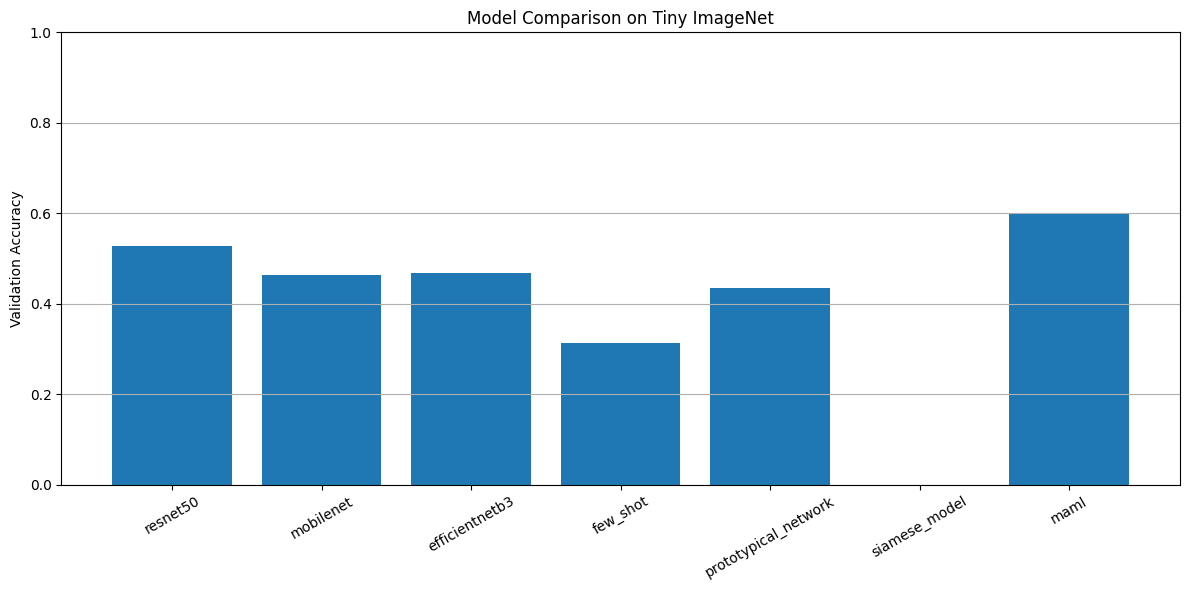

In [ ]:
import json
import matplotlib.pyplot as plt

#Load accuracy results
with open("evaluation_results.json", "r") as f:
    results = json.load(f)

model_names = list(results.keys())
val_accuracies = [results[model]["accuracy"] for model in model_names]

plt.figure(figsize=(12, 6))
plt.bar(model_names, val_accuracies)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison on Tiny ImageNet")
plt.xticks(rotation=30)
plt.ylim(0, 1.0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

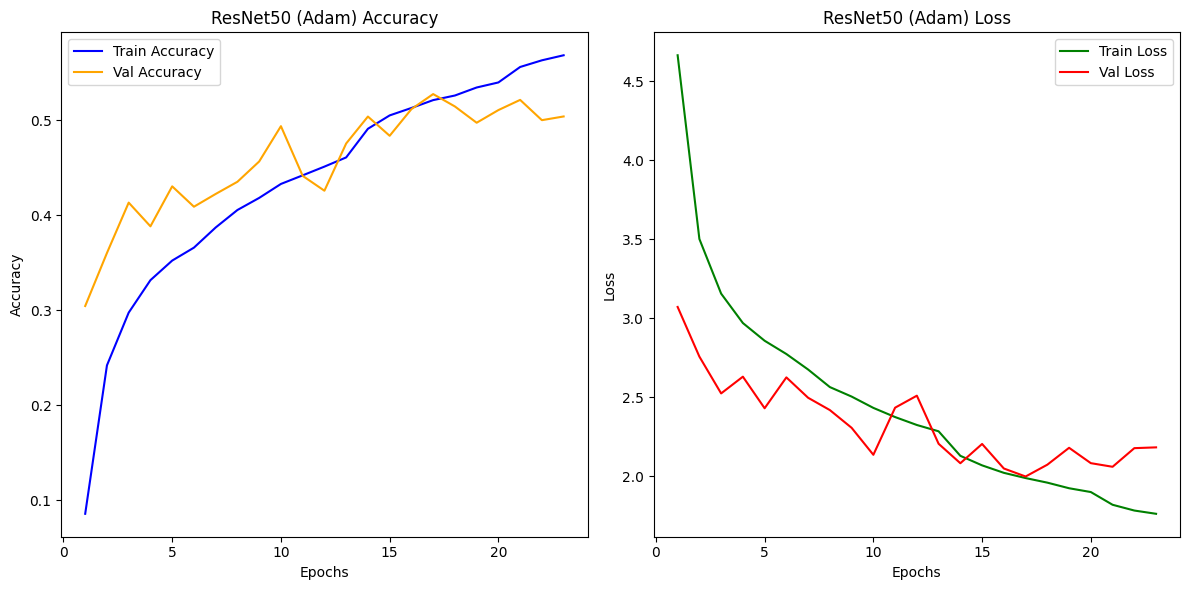

In [117]:
import json
import matplotlib.pyplot as plt

def plot_metrics(json_file, title_prefix):
    with open(json_file, "r") as f:
        data = json.load(f)

    epochs = list(range(1, len(data["accuracy"]) + 1))

    plt.figure(figsize=(12, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, data["accuracy"], label="Train Accuracy", color="blue")
    plt.plot(epochs, data["val_accuracy"], label="Val Accuracy", color="orange")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, data["loss"], label="Train Loss", color="green")
    plt.plot(epochs, data["val_loss"], label="Val Loss", color="red")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics("resnet50_adam_full_metrics.json", "ResNet50 (Adam)")


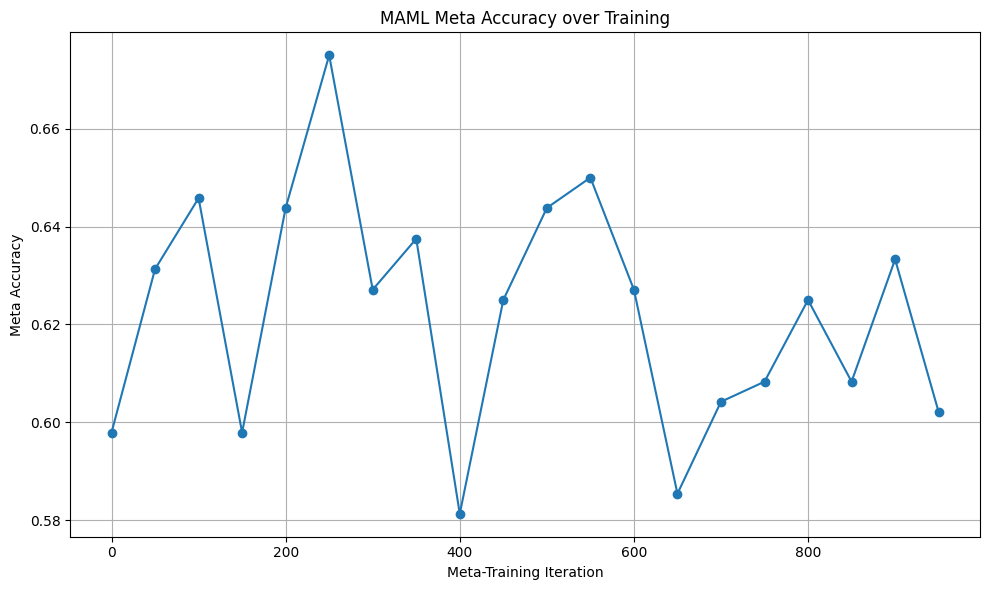

In [79]:
import matplotlib.pyplot as plt

meta_iterations = list(range(0, 1000, 50))
meta_acc = [0.5979, 0.6313, 0.6458, 0.5979, 0.6438, 0.6750, 0.6271, 0.6375, 0.5813,
            0.6250, 0.6438, 0.6500, 0.6271, 0.5854, 0.6042, 0.6083, 0.6250, 0.6083,
            0.6333, 0.6021]

plt.figure(figsize=(10, 6))
plt.plot(meta_iterations, meta_acc, marker='o')
plt.xlabel("Meta-Training Iteration")
plt.ylabel("Meta Accuracy")
plt.title("MAML Meta Accuracy over Training")
plt.grid(True)
plt.tight_layout()
plt.show()

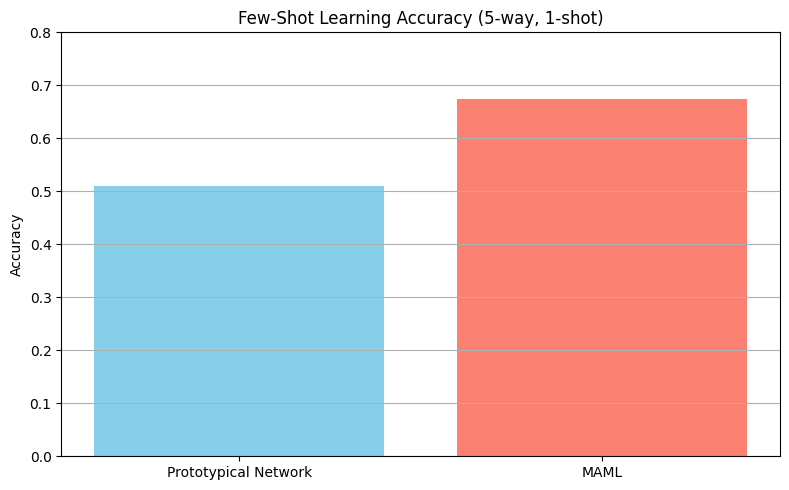

In [86]:
import matplotlib.pyplot as plt

approaches = ["Prototypical Network", "MAML"]
fs_accuracies = [0.5107, 0.6750]

plt.figure(figsize=(8, 5))
plt.bar(approaches, fs_accuracies, color=["skyblue", "salmon"])
plt.title("Few-Shot Learning Accuracy (5-way, 1-shot)")
plt.ylabel("Accuracy")
plt.ylim(0, 0.8)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

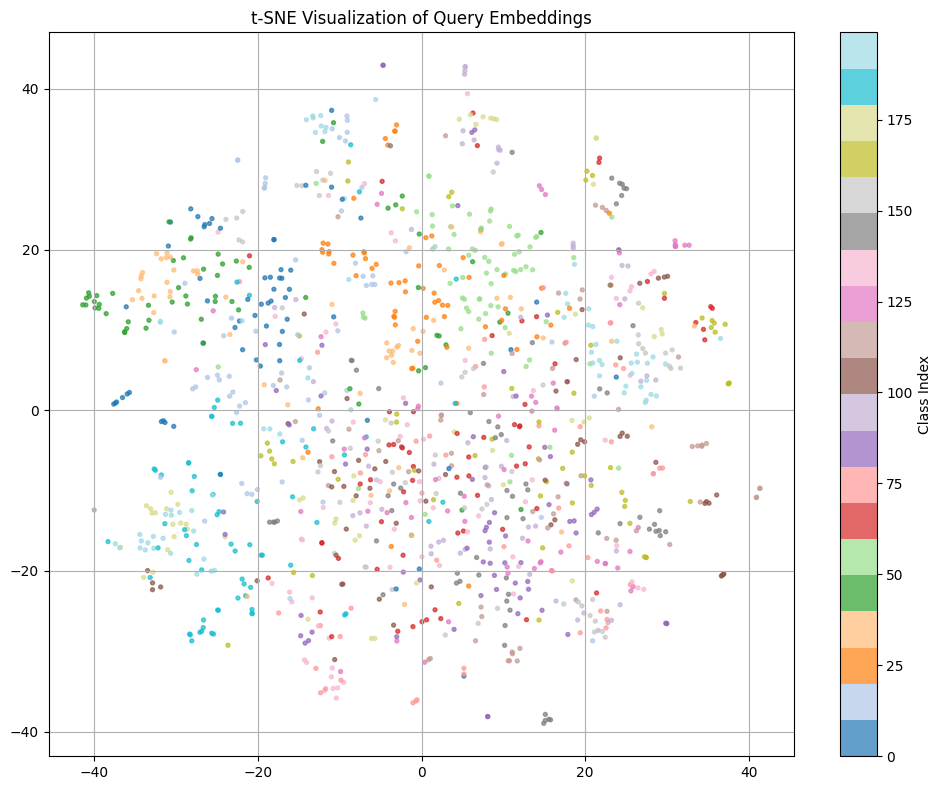

In [80]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
features = np.load("all_query_features.npy")
labels = np.load("all_query_labels.npy")

num_samples = min(3000, len(features))  # pick 3000 or less depending on what's available
indices = np.random.choice(len(features), num_samples, replace=False)
features_subset = features[indices]
labels_subset = labels[indices]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced = tsne.fit_transform(features_subset)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels_subset, cmap='tab20', s=8, alpha=0.7)
plt.colorbar(scatter, label="Class Index")
plt.title("t-SNE Visualization of Query Embeddings")
plt.grid(True)
plt.tight_layout()
plt.show()